In [1]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [2]:
# Make sure that the working directory is the project root.
%cd -q ../

In [3]:
import torch
import pickle
import numpy as np
from autoregltl import ted, llama, mamba, dataset
from autoregltl.ltl import trace_check

from tqdm.auto import tqdm
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 192
mpl.rcParams['svg.fonttype'] = 'none'  # Critical: don't convert text to paths
plt.rcParams['pdf.use14corefonts'] = True

device = torch.device('cuda')

In [4]:
redgreen = mpl.colors.LinearSegmentedColormap(
    "redgreen",
    {
        'red': (
            (0.0, 1.0, 1.0),
            (0.15873*3, 1.0, 1.0),
            (0.174603*3, 0.96875, 0.96875),
            (1.0, 0.0, 0.0),
        ),
        'green': (
            (0.0, 0.0, 0.0),
            (0.15873*3, 0.9375, 0.9375),
            (0.174603*3, 1.0, 1.0),
            (1.0, 1.0, 1.0),
        ),
        'blue': (
            (0.0, 0.0, 0.0),
            (1.0, 0.0, 0.0),
        ),
    }
)

In [5]:
def read_eval2da(filename):
    with open(filename, 'rb') as f: evaldict = pickle.load(f)
    #torch.load(filename, map_location=torch.device('cpu'))
    # dict_keys(['correct_matrix', 'count_matrix', 'correct', 'count', 'repeat_count', 'eval_ds', 'all_results'])
        
    count_matrix = evaldict['count_matrix']
    correct_matrix = evaldict['correct_matrix']
    sample_rate = count_matrix / 100.0
    eval_results = torch.where(count_matrix > 0, correct_matrix / count_matrix, 0.0)

    return eval_results, sample_rate, evaldict['correct'], evaldict['count']

# LTL

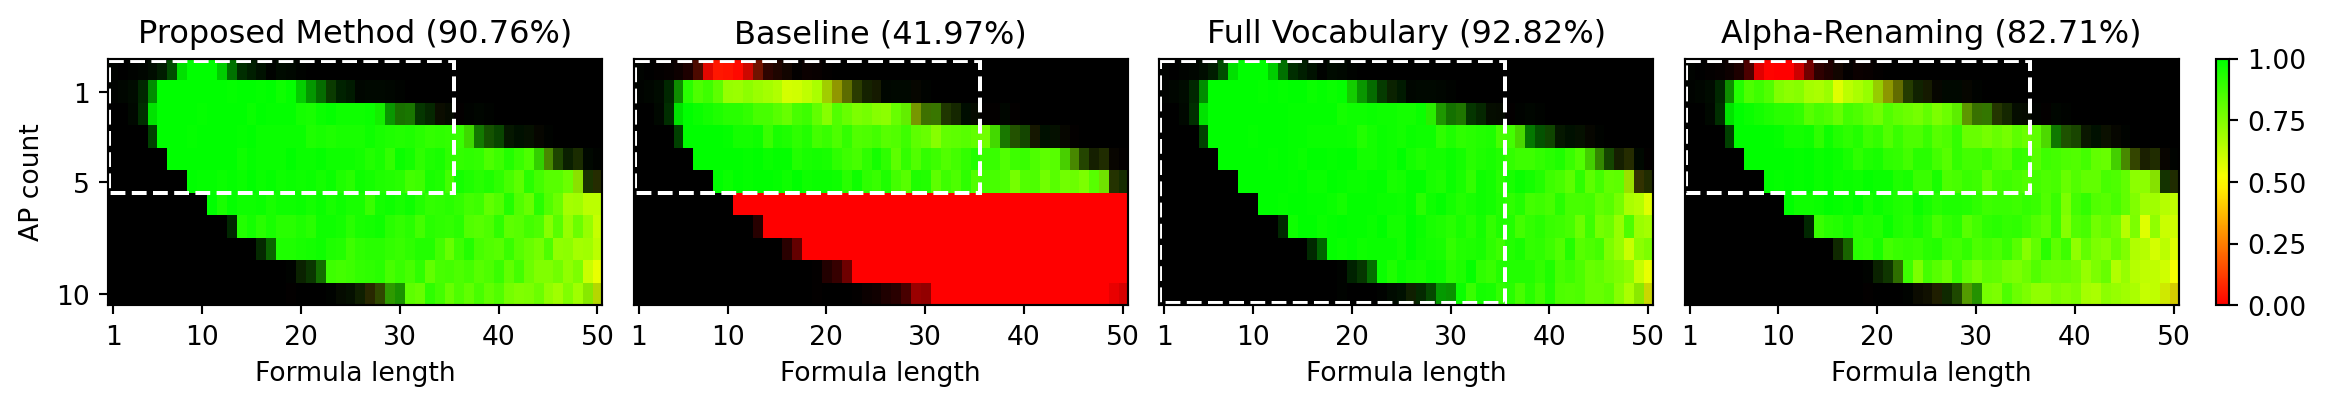

In [6]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(12, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs[0]
eval_results, sample_rate, correct, count = read_eval2da("./models/ltl-5/d005-rop-bn1-fn1-ada1-s42/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10+1, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"Proposed Method ({100.0*correct/count:.2f}%)")

yticks = []
full_count = count

ax = axs[1]
eval_results, sample_rate, correct, count = read_eval2da("./models/adacos/nondyn-rope/eval2da1.pkl")
eval_fixed = torch.zeros(10+1, 50)
eval_fixed[:eval_results.size(0), :eval_results.size(1)] = eval_results
ax.imshow(eval_fixed, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"Baseline ({100.0*correct/full_count:.2f}%)")

ax = axs[2]
eval_results, sample_rate, correct, count = read_eval2da("./models/10ap/adacos-nondyn/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 10+1-.2, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Full Vocabulary ({100.0*correct/full_count:.2f}%)")

ax = axs[3]
eval_results, sample_rate, correct, count = read_eval2da("./models/ltl-5/s010-rop-bn1-fn1-ada1-s46/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Alpha-Renaming ({100.0*correct/full_count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("ltl-heatmap.pdf")

Before Augmenting & 82.71%
After Augmenting & 90.15%


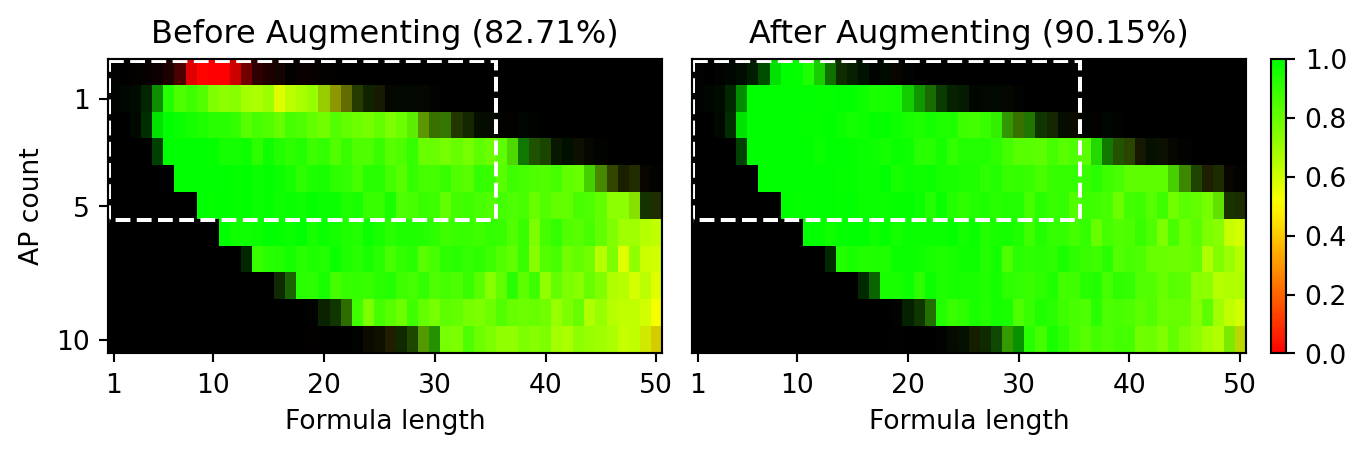

In [8]:
# Plot
models = [
    ("Before Augmenting", "../mare/deepltl-models/ltl-5/s010-rop-bn1-fn1-ada1-s46/eval2da1.pkl"),
    ("After Augmenting", "./models-scc/reverse/s010-44/eval2da1.pkl"),
]
fig, axs = plt.subplots(ncols=len(models), nrows=1, figsize=(3.5*len(models), 2.25),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

for i, (ax, model) in enumerate(zip(axs, models)):
    title, model_path = model
    eval_results, sample_rate, correct, count = read_eval2da(model_path)
    ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
    # Plotting the modulus array as the 'value' part
    black = torch.zeros(10+1, 50, 4)
    black[:, :, -1] = 1.0 - sample_rate
    #black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
    ax.imshow(black, **common_kwargs)
    
    if i == 0:
        ax.set_ylabel("AP count")
    ax.set_xlabel("Formula length")
    ax.set_xticks([i -1 for i in xticks], xticks)
    ax.set_yticks(yticks, yticks)
    # # 35 is not actually inclusive
    ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
    ax.set_title(f"{title} ({100.0*correct/count:.2f}%)")
    print(f"{title} & {100.0*correct/count:.2f}%")
    
    yticks = []
    full_count = count

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("ltl-augment-alpha-renaming.pdf")

## Ablation

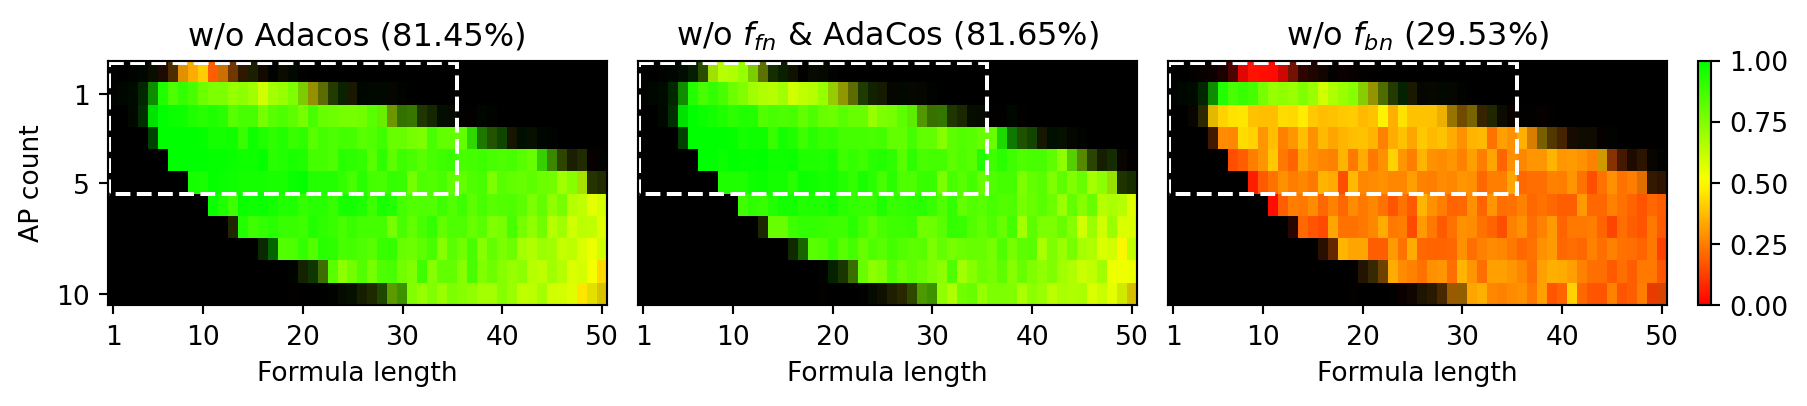

In [7]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(9.3, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs[0]
eval_results, sample_rate, correct, count = read_eval2da("models/ltl-5/d005-rop-bn1-fn1-ada0-s42/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10+1, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"w/o Adacos ({100.0*correct/count:.2f}%)")

yticks = []
full_count = count

ax = axs[1]
eval_results, sample_rate, correct, count = read_eval2da("models/ltl-5/d005-rop-bn1-fn0-ada0-s42/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"w/o $f_{{fn}}$ & AdaCos ({100.0*correct/full_count:.2f}%)")

ax = axs[2]
eval_results, sample_rate, correct, count = read_eval2da("models/ltl-5/d005-rop-bn0-fn1-ada1-s42/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"w/o $f_{{bn}}$ ({100.0*correct/full_count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("ltl-abl.pdf")

# LTL New

In [32]:
! (cd models-scc; python eval2da-leaderboard.py | grep ns0-per-s)

./reverse-epat/ns0-per-s92/eval2da1.pkl: 89.47%
./reverse-epat/ns0-per-s91/eval2da1.pkl: 88.63%
./reverse-epat/ns0-per-s90/eval2da1.pkl: 88.41%


In [33]:
! (cd models-scc; python eval2da-leaderboard.py | grep ns0-nocos-per-s)

./reverse-epat/ns0-nocos-per-s43/eval2da1.pkl: 89.11%
./reverse-epat/ns0-nocos-per-s44/eval2da1.pkl: 88.11%
./reverse-epat/ns0-nocos-per-s45/eval2da1.pkl: 87.93%
./reverse-epat/ns0-nocos-per-s42/eval2da1.pkl: 87.00%


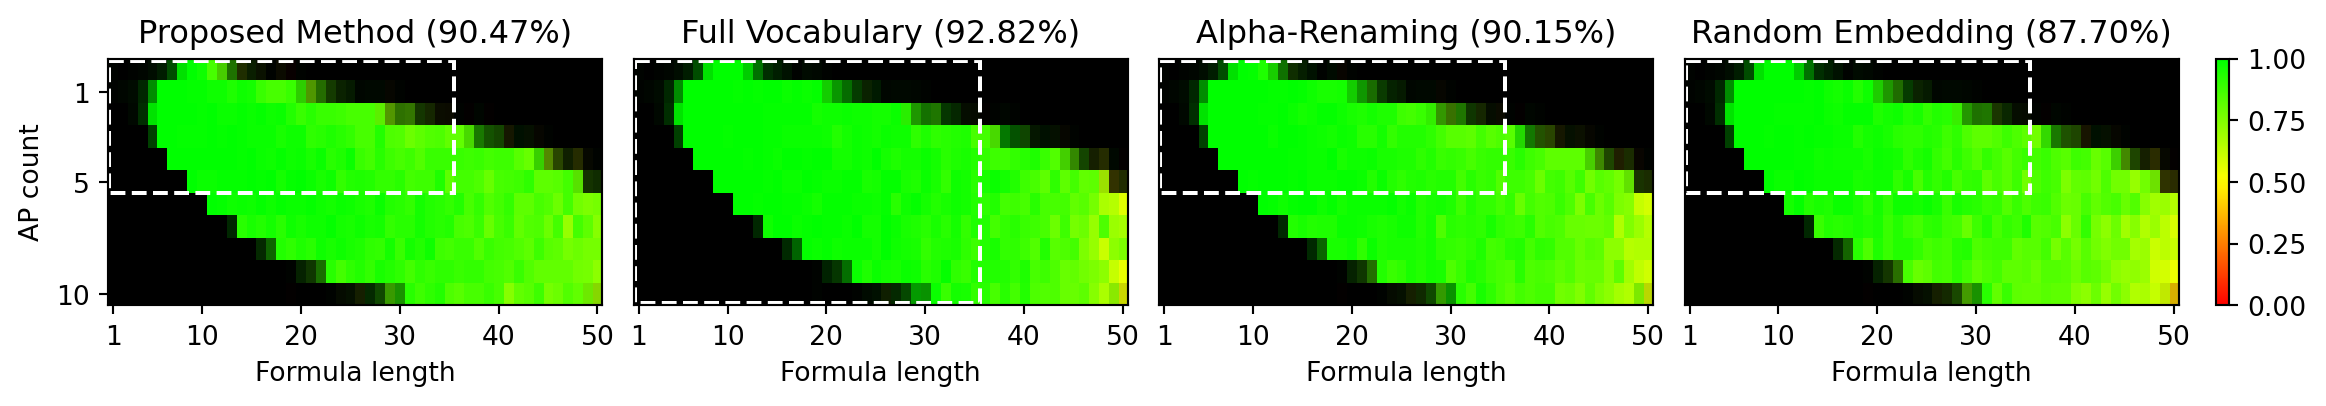

In [9]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(12, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs[0]
eval_results, sample_rate, correct, count = read_eval2da("./models-scc/reverse-epat/ns0-per-noda-s46/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10+1, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"Proposed Method ({100.0*correct/count:.2f}%)")

yticks = []
full_count = count

ax = axs[1]
eval_results, sample_rate, correct, count = read_eval2da("../mare/deepltl-models/10ap/adacos-nondyn/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 10+1-.2, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Full Vocabulary ({100.0*correct/full_count:.2f}%)")

ax = axs[2]
eval_results, sample_rate, correct, count = read_eval2da("./models-scc/reverse/s010-44/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Alpha-Renaming ({100.0*correct/full_count:.2f}%)")

ax = axs[3]
eval_results, sample_rate, correct, count = read_eval2da("./models-scc/reverse/d005-43/eval2da1.pkl")
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Random Embedding ({100.0*correct/full_count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("ltl-heatmap.pdf")

# New LTL Abl

In [31]:
! (cd models-scc; python eval2da-leaderboard.py)

File path and accuracies sorted by descending accuracy:
./reverse/s010-batch1024-46/eval2da1.pkl: 90.51%
./reverse/s010-44/eval2da1.pkl: 90.15%
./reverse/s010-46/eval2da1.pkl: 89.84%
./reverse/s010-42/eval2da1.pkl: 89.66%
./reverse/s010-43/eval2da1.pkl: 89.63%
./reverse-epat/ns0-per-s92/eval2da1.pkl: 89.47%
./reverse-epat/ns0-nocos-per-s43/eval2da1.pkl: 89.11%
./reverse-epat/ns0-nocos-peragg-s92/eval2da1.pkl: 88.83%
./reverse-epat/ns0-nocos-s43/eval2da1.pkl: 88.68%
./reverse-epat/ns0-per-s91/eval2da1.pkl: 88.63%
./reverse-epat/ns0-s43/eval2da1.pkl: 88.44%
./reverse-epat/ns0-per-s90/eval2da1.pkl: 88.41%
./reverse-epat/ns0-nocos-per-s44/eval2da1.pkl: 88.11%
./reverse-epat/ns0-nocos-per-s45/eval2da1.pkl: 87.93%
./reverse-epat/small0-s43-fine/eval2da1.pkl: 87.87%
./reverse-epat/ns0-nocos-peragg-s93/eval2da1.pkl: 87.78%
./reverse/d005-43/eval2da1.pkl: 87.70%
./reverse/d005-42/eval2da1.pkl: 87.56%
./reverse/d005-batch1024-42/eval2da1.pkl: 87.34%
./reverse/d005-batch1024-43/eval2da1.pkl: 87.3

In [14]:
! (cd models-scc; python eval2da-leaderboard.py | grep noeda)

./reverse-epat/ns0-nocos-per-noeda-s42/eval2da1.pkl: 83.10%


Default & 89.47%
+4B & 88.83%
-4A +4B & 22.83%
-3E & 86.44%
-3D & 87.06%
-3E -3D & 83.10%


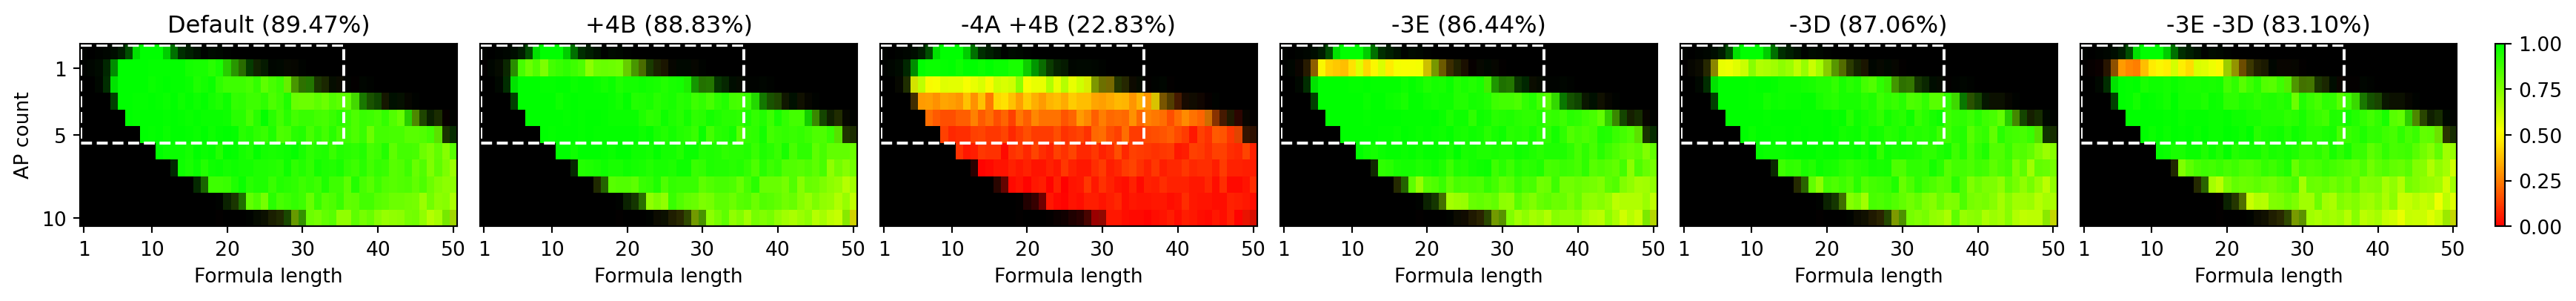

In [7]:
# Plot
models = [
    ("Default", "models-scc/reverse-epat/ns0-per-s92/eval2da1.pkl"),
    # TODO: nocos to cos???
    ("+4B", "models-scc/reverse-epat/ns0-nocos-peragg-s92/eval2da1.pkl"),
    ("-4A +4B", "models-scc/reverse-epat/ns0-nocos-agg-s12/eval2da1.pkl"),
    ("-3E", "models-scc/reverse-epat/ns0-nocos-per-noea-s42/eval2da1.pkl"),
    ("-3D", "models-scc/reverse-epat/ns0-nocos-per-noda-s42/eval2da1.pkl"),
    ("-3E -3D", "models-scc/reverse-epat/ns0-nocos-per-noeda-s42/eval2da1.pkl"),
]
fig, axs = plt.subplots(ncols=len(models), nrows=1, figsize=(3*len(models), 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

for i, (ax, model) in enumerate(zip(axs, models)):
    title, model_path = model
    eval_results, sample_rate, correct, count = read_eval2da(model_path)
    ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
    # Plotting the modulus array as the 'value' part
    black = torch.zeros(10+1, 50, 4)
    black[:, :, -1] = 1.0 - sample_rate
    #black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
    ax.imshow(black, **common_kwargs)
    
    if i == 0:
        ax.set_ylabel("AP count")
    ax.set_xlabel("Formula length")
    ax.set_xticks([i -1 for i in xticks], xticks)
    ax.set_yticks(yticks, yticks)
    # # 35 is not actually inclusive
    ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5+1-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
    ax.set_title(f"{title} ({100.0*correct/count:.2f}%)")
    print(f"{title} & {100.0*correct/count:.2f}%")
    
    yticks = []
    full_count = count

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

#plt.savefig("ltl-abl.pdf")

# Prop

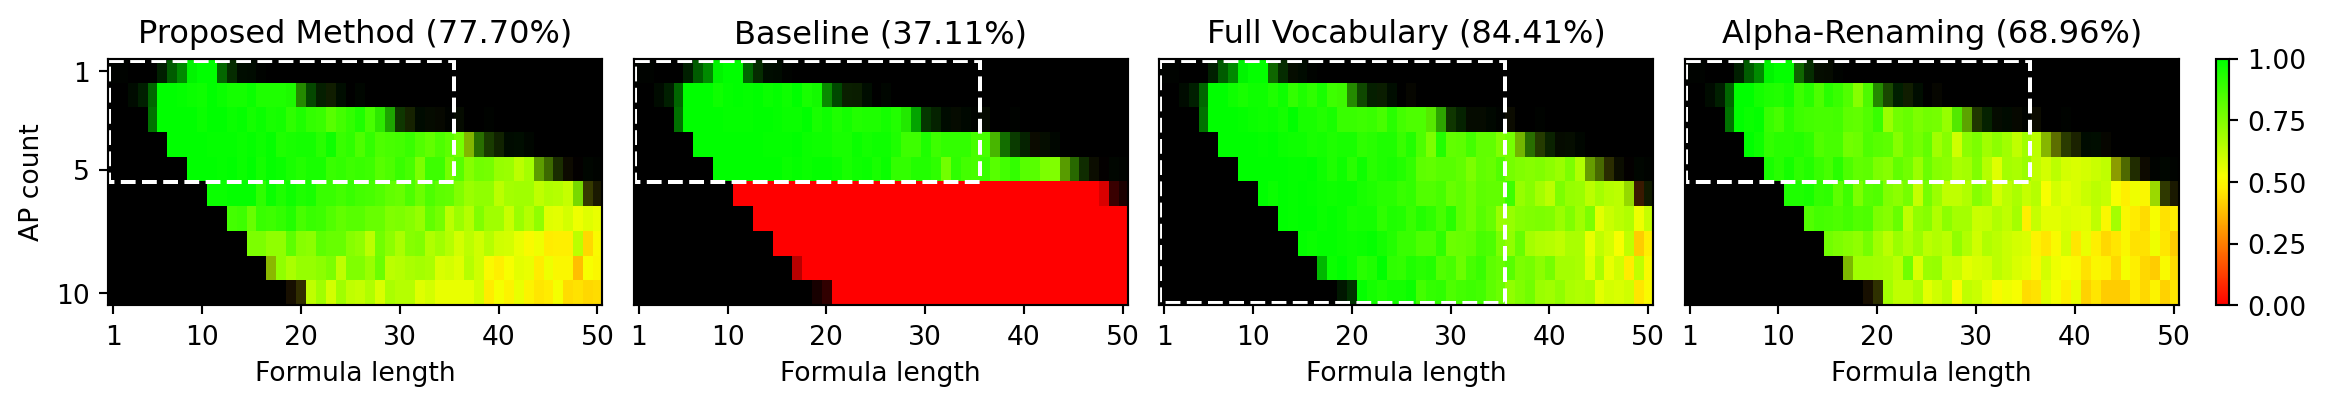

In [8]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(12, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs[0]
eval_results, sample_rate, correct, count = read_eval2da("models-prop/5ap/d020-rop-bn1-fn1-ada1-s44/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks([i-1 for i in yticks], yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"Proposed Method ({100.0*correct/count:.2f}%)")

yticks = []
full_count = count

ax = axs[1]
eval_results, sample_rate, correct, count = read_eval2da("models-prop/5ap/0000-rop-bn0-fn1-ada1-s42/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
eval_fixed = torch.zeros(10+1, 50)
eval_fixed[:eval_results.size(0), :eval_results.size(1)] = eval_results
ax.imshow(eval_fixed, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"Baseline ({100.0*correct/full_count:.2f}%)")

ax = axs[2]
eval_results, sample_rate, correct, count = read_eval2da("models-prop/10ap/0000-rop-bn0-fn1-ada1-s43/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 10-.2, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Full Vocabulary ({100.0*correct/full_count:.2f}%)")

ax = axs[3]
eval_results, sample_rate, correct, count = read_eval2da("models-prop/5ap/s010-rop-bn1-fn1-ada1-s44/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Alpha-Renaming ({100.0*correct/full_count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("prop-heatmap.pdf")

## Prop Abl

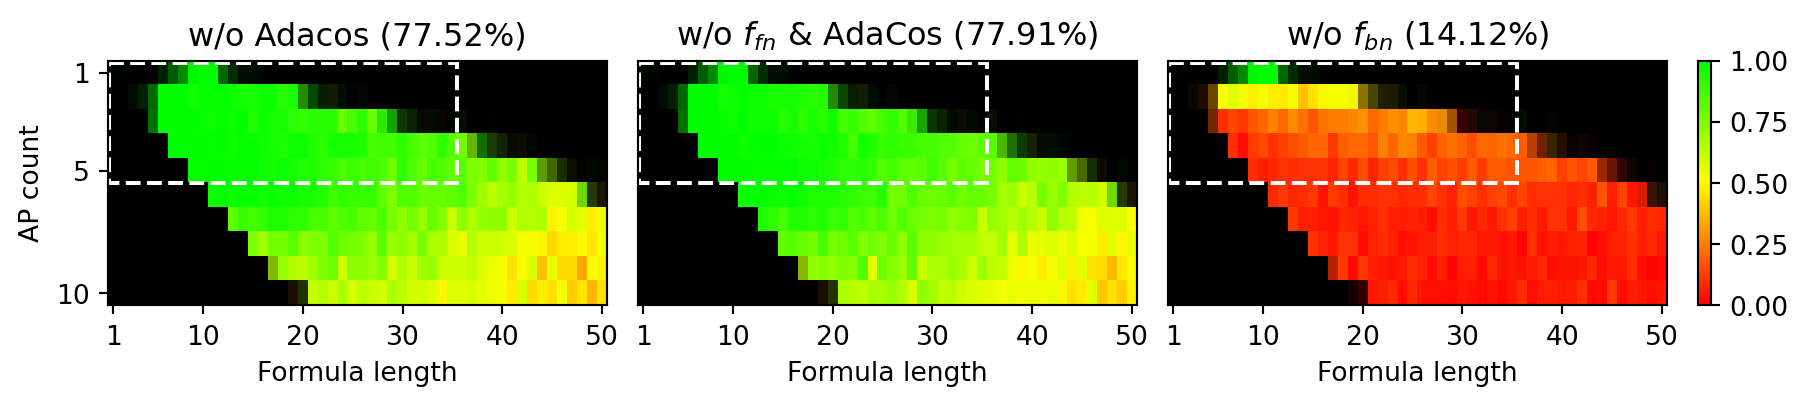

In [9]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(9.3, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs[0]
eval_results, sample_rate, correct, count = read_eval2da("models-prop/5ap/d020-rop-bn1-fn1-ada0-s43/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks([i-1 for i in yticks], yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"w/o Adacos ({100.0*correct/count:.2f}%)")

yticks = []
full_count = count

ax = axs[1]
eval_results, sample_rate, correct, count = read_eval2da("models-prop/5ap/d020-rop-bn1-fn0-ada0-s44/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"w/o $f_{{fn}}$ & AdaCos ({100.0*correct/full_count:.2f}%)")

ax = axs[2]
eval_results, sample_rate, correct, count = read_eval2da("models-prop/5ap/d020-rop-bn0-fn1-ada1-s42/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"w/o $f_{{bn}}$ ({100.0*correct/full_count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("prop-abl.pdf")

# New Prop

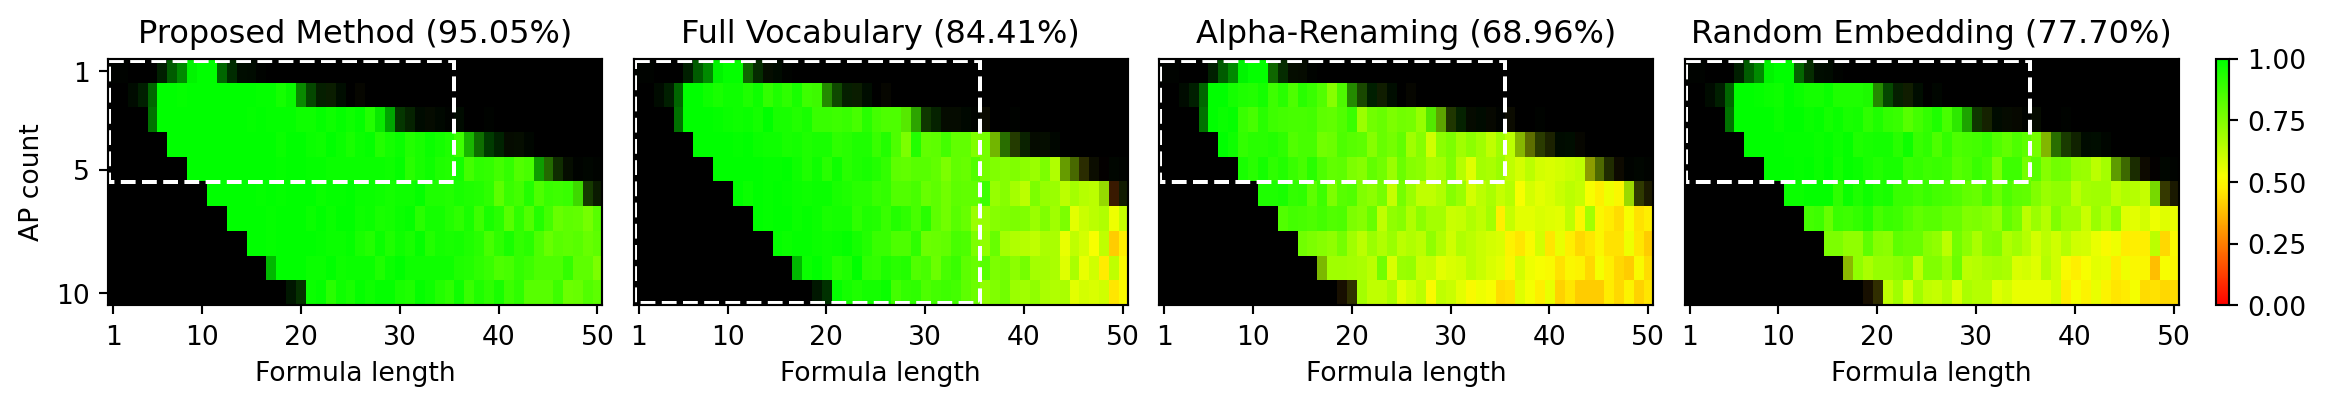

In [11]:
# Plot
#fig, ax = plt.subplots(figsize=(6,3))
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(12, 2),
                        #width_ratios=[3, 3, 3],
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

ax = axs[0]
eval_results, sample_rate, correct, count = read_eval2da("./models-scc/reverse-prop-epat/s1-43/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
# Plotting the modulus array as the 'value' part
black = torch.zeros(10, 50, 4)
black[:, :, -1] = 1.0 - sample_rate
#black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
ax.imshow(black, **common_kwargs)

ax.set_ylabel("AP count")
ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks([i-1 for i in yticks], yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
ax.set_title(f"Proposed Method ({100.0*correct/count:.2f}%)")

yticks = []
full_count = count

ax = axs[1]
eval_results, sample_rate, correct, count = read_eval2da("../mare/models-prop/10ap/0000-rop-bn0-fn1-ada1-s43/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 10-.2, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Full Vocabulary ({100.0*correct/full_count:.2f}%)")

ax = axs[2]
eval_results, sample_rate, correct, count = read_eval2da("../mare/models-prop/5ap/s010-rop-bn1-fn1-ada1-s44/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Alpha-Renaming ({100.0*correct/full_count:.2f}%)")

ax = axs[3]
eval_results, sample_rate, correct, count = read_eval2da("../mare/models-prop/5ap/d020-rop-bn1-fn1-ada1-s44/eval2da1.pkl")
eval_results = eval_results[1:, :]
sample_rate = sample_rate[1:, :]
ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
ax.imshow(black, **common_kwargs)

ax.set_xlabel("Formula length")
ax.set_xticks([i -1 for i in xticks], xticks)
ax.set_yticks(yticks, yticks)
# # 35 is not actually inclusive
ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
assert(count == full_count)
ax.set_title(f"Random Embedding ({100.0*correct/full_count:.2f}%)")

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("prop-heatmap.pdf")

# New Prop Abl

In [16]:
! (cd models-scc; python eval2da-leaderboard.py --prop)

File path and accuracies sorted by descending accuracy:
./reverse-prop-epat/s1-43/eval2da1.pkl: 95.05%
./reverse-prop-epat/nerc/s1-ff512-42/eval2da1.pkl: 94.96%
./reverse-prop-epat/s1-44/eval2da1.pkl: 94.78%
./reverse-prop-epat/s1n-42/eval2da1.pkl: 94.67%
./reverse-prop-epat/s1n-43/eval2da1.pkl: 94.38%
./reverse-prop-epat/s2n-44/eval2da1.pkl: 94.15%
./reverse-prop-epat/s1n-44/eval2da1.pkl: 94.11%
./reverse-prop-epat/s1-42/eval2da1.pkl: 93.98%
./reverse-prop-epat/s2-44/eval2da1.pkl: 93.81%
./reverse-prop-epat/s1-peragg-13/eval2da1.pkl: 92.66%
./reverse-prop-epat/s1-peragg-12/eval2da1.pkl: 92.62%
./reverse-prop-epat/s1-noea-90/eval2da1.pkl: 92.47%
./reverse-prop-epat/s0-44/eval2da1.pkl: 91.79%
./reverse-prop-epat/nerc/s1-peragg-noea-42/eval2da1.pkl: 91.10%
./reverse-prop-epat/nerc/s1-per-noea-42/eval2da1.pkl: 90.36%
./reverse-prop-epat/s1-peragg-noea-90/eval2da1.pkl: 89.63%
./reverse-prop/nerc/full-ff768-h96-42/eval2da1.pkl: 84.89%
./reverse-prop-epat/s1-noda-90/eval2da1.pkl: 84.48%
./re

In [24]:
! (cd models-scc; python eval2da-leaderboard.py --prop | grep no)

./reverse-prop-epat/s1-noea-90/eval2da1.pkl: 92.47%
./reverse-prop-epat/nerc/s1-peragg-noea-42/eval2da1.pkl: 91.10%
./reverse-prop-epat/nerc/s1-per-noea-42/eval2da1.pkl: 90.36%
./reverse-prop-epat/s1-peragg-noea-90/eval2da1.pkl: 89.63%
./reverse-prop-epat/s1-noda-90/eval2da1.pkl: 84.48%
./reverse-prop-epat/s1-peragg-noda-90/eval2da1.pkl: 84.33%
./reverse-prop-epat/nerc/s1-per-noda-42/eval2da1.pkl: 84.13%
./reverse-prop-epat/nerc/s1-peragg-noda-42/eval2da1.pkl: 82.76%
./reverse-prop-epat/s1-noeada-42/eval2da1.pkl: 72.35%


Default & 95.05%
+4B & 92.66%
-4A +4B & 28.51%
-3E & 92.47%
-3D & 84.48%
-3E -3D & 72.35%


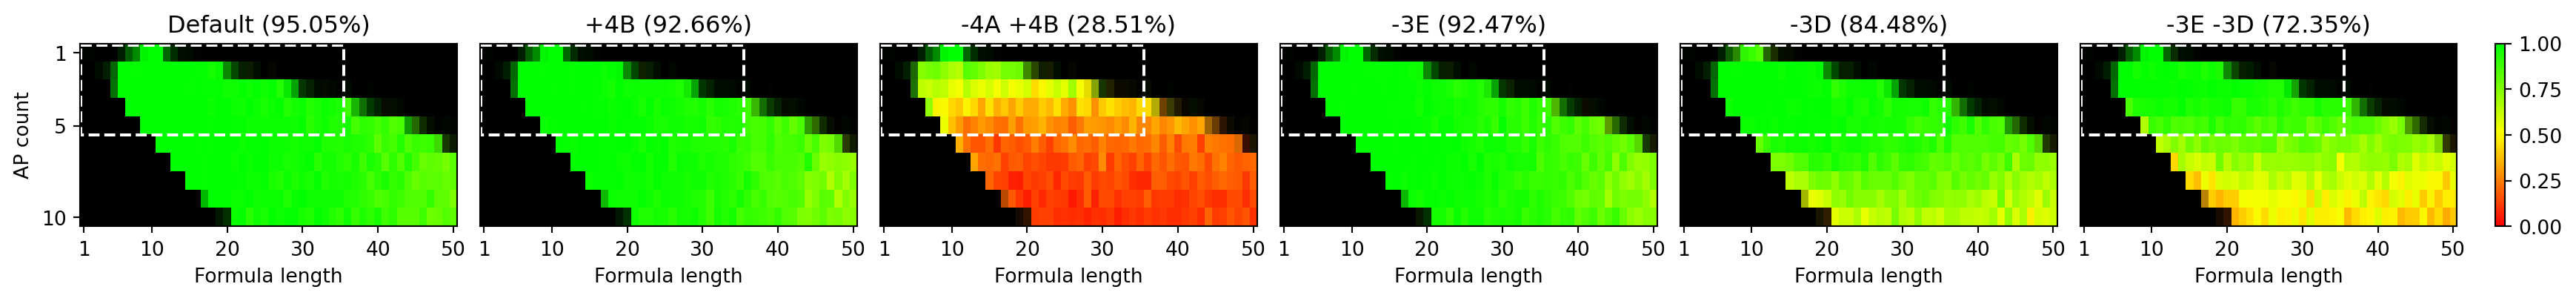

In [29]:
# Plot
models = [
    ("Default", "models-scc/reverse-prop-epat/s1-43/eval2da1.pkl"),
    ("+4B", "models-scc/reverse-prop-epat/s1-peragg-13/eval2da1.pkl"),
    ("-4A +4B", "models-scc/reverse-prop-epat/s1-agg-42/eval2da1.pkl"),
    ("-3E", "models-scc/reverse-prop-epat/s1-noea-90/eval2da1.pkl"),
    ("-3D", "models-scc/reverse-prop-epat/s1-noda-90/eval2da1.pkl"),
    ("-3E -3D", "models-scc/reverse-prop-epat/s1-noeada-42/eval2da1.pkl"),
]

fig, axs = plt.subplots(ncols=len(models), nrows=1, figsize=(3*len(models), 2),
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

for i, (ax, model) in enumerate(zip(axs, models)):
    title, model_path = model
    eval_results, sample_rate, correct, count = read_eval2da(model_path)
    eval_results = eval_results[1:, :]
    sample_rate = sample_rate[1:, :]
    ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
    # Plotting the modulus array as the 'value' part
    black = torch.zeros(10, 50, 4)
    black[:, :, -1] = 1.0 - sample_rate
    #black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
    ax.imshow(black, **common_kwargs)
    
    if i == 0:
        ax.set_ylabel("AP count")
    ax.set_xlabel("Formula length")
    ax.set_xticks([i -1 for i in xticks], xticks)
    ax.set_yticks([i-1 for i in yticks], yticks)
    # # 35 is not actually inclusive
    ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
    ax.set_title(f"{title} ({100.0*correct/count:.2f}%)")
    print(f"{title} & {100.0*correct/count:.2f}%")
    
    yticks = []
    full_count = count

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

#plt.savefig("prop-abl.pdf")

FileNotFoundError: [Errno 2] No such file or directory: '../mare/models-prop/5ap/d020-rop-bn1-fn1-ada1-s43/eval2da1.pkl'

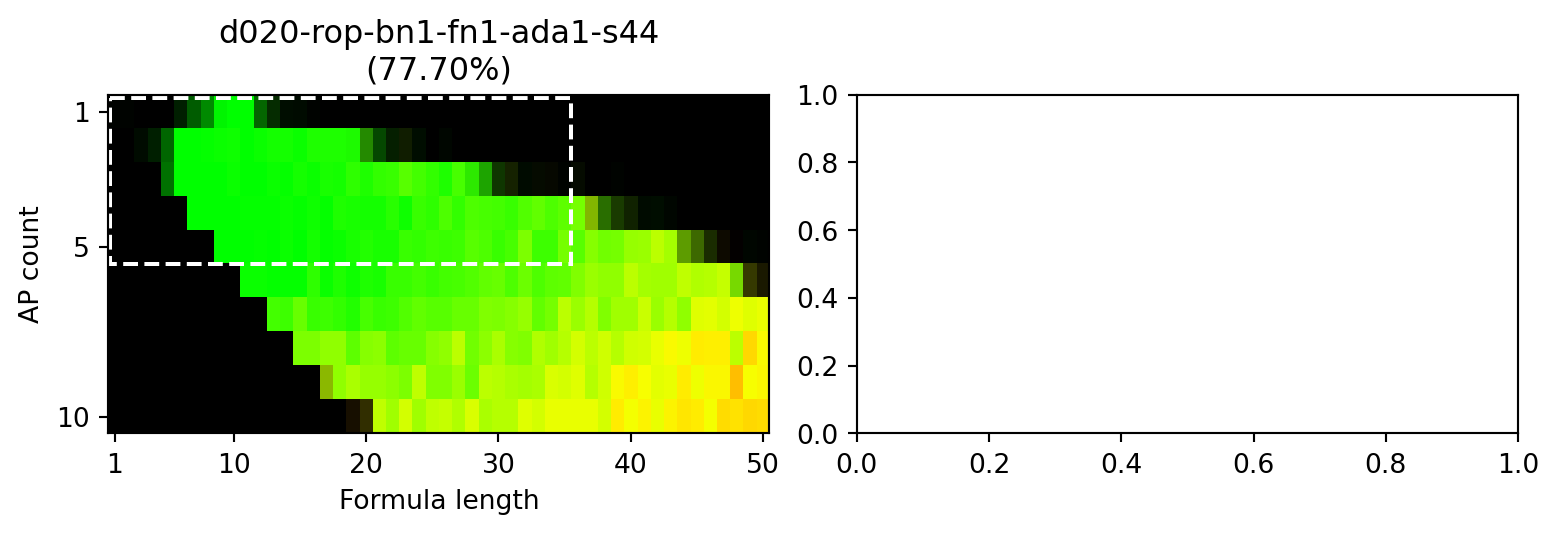

In [20]:
# Plot
models = [
    #"../mare/models-prop/5ap/d020-rop-bn1-fn1-ada1-s42/eval2da1.pkl",
    #"../mare/models-prop/5ap/d020-rop-bn1-fn1-ada1-s43/eval2da1.pkl",
    "../mare/models-prop/5ap/d020-rop-bn1-fn1-ada1-s44/eval2da1.pkl",
    "../mare/models-prop/5ap/d020-rop-bn1-fn1-ada1-s43/eval2da1.pkl",
]

fig, axs = plt.subplots(ncols=len(models), nrows=1, figsize=(4*len(models), 4*2/3),
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]

for ax, model in zip(axs, models):
    eval_results, sample_rate, correct, count = read_eval2da(model)
    eval_results = eval_results[1:, :]
    sample_rate = sample_rate[1:, :]
    ax.imshow(eval_results, cmap=redgreen, vmin=0.0, vmax=1.0, **common_kwargs)
    # Plotting the modulus array as the 'value' part
    black = torch.zeros(10, 50, 4)
    black[:, :, -1] = 1.0 - sample_rate
    #black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
    ax.imshow(black, **common_kwargs)
    
    ax.set_ylabel("AP count")
    ax.set_xlabel("Formula length")
    ax.set_xticks([i -1 for i in xticks], xticks)
    ax.set_yticks([i-1 for i in yticks], yticks)
    # # 35 is not actually inclusive
    ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
    model_name = model.split('/')[-2]
    ax.set_title(f"{model_name}\n({100.0*correct/count:.2f}%)")
    
    yticks = []
    full_count = count

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen), ax=axs, pad=0.0125)
#fig.tight_layout()

In [12]:
axs

<Axes: >